# 06_experiments_lr_5e-5

## Controlled experiment — learning rate 5e-5

**What this does:** repeats the fine-tuning setup with a learning rate of `5e-5`.

**Why:** comparing this run with E3 at `2e-5` changes one meaningful variable while keeping the rest of the configuration fixed.


In [1]:
# This notebook is the 5e-5 arm of the controlled experiment.
# The tokenizer, split, model, batch size, epochs, and seed remain unchanged.
# This is the 5e-5 branch of the controlled learning-rate experiment.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import json
from src.data.load_data import load_banking77
from src.models.transformer import run_transformer_experiment
dataset = load_banking77(validation_size=0.1, seed=42)
result = run_transformer_experiment(dataset, frozen=False, learning_rate=5e-05, epochs=3, max_length=64, seed=42)
print({"history": result["history"], "training_seconds": result["training_seconds"], "trainable_parameters": result["trainable_parameters"], "total_parameters": result["total_parameters"]})
Path("results/logs").mkdir(parents=True, exist_ok=True)
Path("results/logs/06_experiments_lr_5e-5_history.json").write_text(json.dumps({"history": result["history"], "training_seconds": result["training_seconds"], "trainable_parameters": result["trainable_parameters"], "total_parameters": result["total_parameters"]}, indent=2))
result["model"].save_pretrained("results/06_experiments_lr_5e-5_checkpoint")
result["tokenizer"].save_pretrained("results/06_experiments_lr_5e-5_checkpoint")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'history': [{'epoch': 1, 'train_loss': 2.020524992674781, 'validation_loss': 0.5856132008038558, 'validation_accuracy': 0.8571428571428571, 'validation_macro_f1': 0.8456489795963263}, {'epoch': 2, 'train_loss': 0.3979887298526194, 'validation_loss': 0.40843129121548644, 'validation_accuracy': 0.8911088911088911, 'validation_macro_f1': 0.8891488517758025}, {'epoch': 3, 'train_loss': 0.19056289768687779, 'validation_loss': 0.3324927343176557, 'validation_accuracy': 0.9150849150849151, 'validation_macro_f1': 0.9129553633439857}], 'training_seconds': 89.3153680439973, 'trainable_parameters': 67012685, 'total_parameters': 67012685}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('results/06_experiments_lr_5e-5_checkpoint/tokenizer_config.json',
 'results/06_experiments_lr_5e-5_checkpoint/tokenizer.json')

## Training curves — E4 Learning rate 5e-5

**What this does:** displays the saved training/validation loss and validation Macro-F1.

**Why:** curves show whether learning is progressing, whether the model is overfitting, and how the best checkpoint was selected.

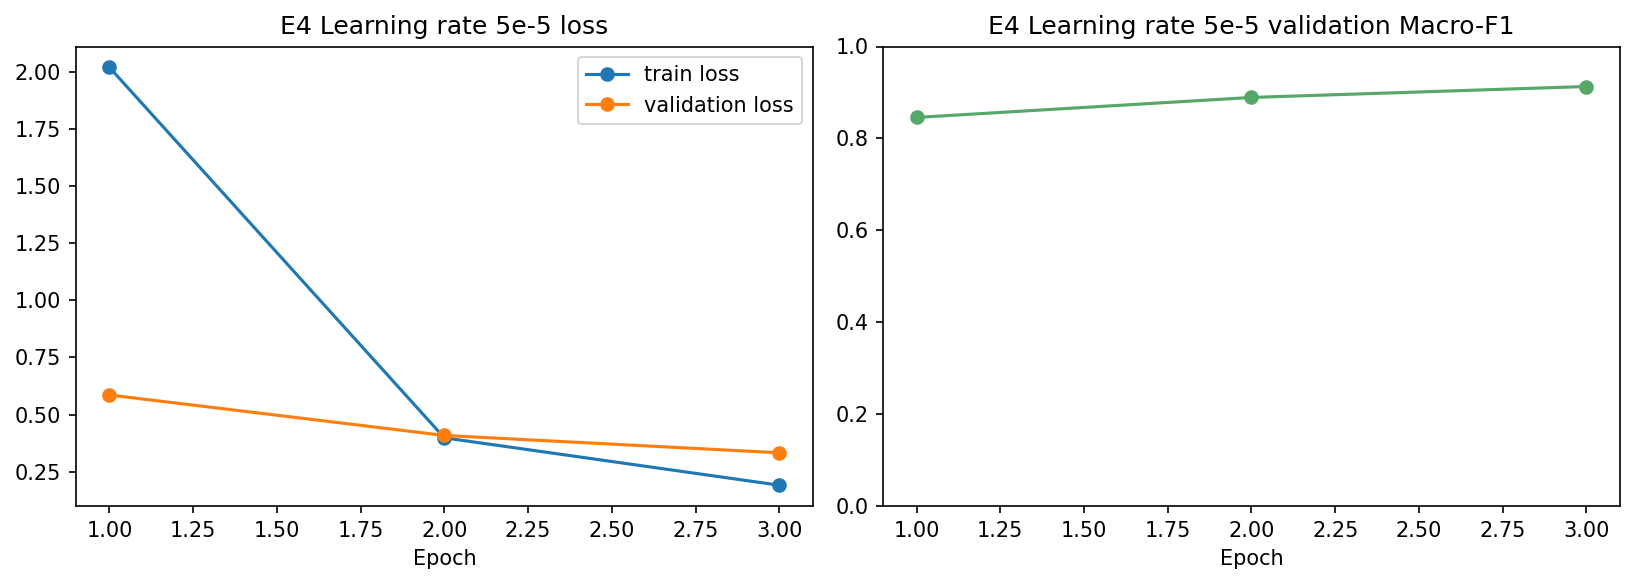

In [ ]:
# Read the saved history produced by the training step.
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().parent
history_file = root / "results/logs/06_experiments_lr_5e-5_history.json"
history_data = json.loads(history_file.read_text())
history = history_data if isinstance(history_data, list) else history_data["history"]
frame = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(frame["epoch"], frame["train_loss"], marker="o", label="train loss")
axes[0].plot(frame["epoch"], frame["validation_loss"], marker="o", label="validation loss")
axes[0].set_title("E4 Learning rate 5e-5 loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(frame["epoch"], frame["validation_macro_f1"], marker="o", color="#55A868")
axes[1].set_title("E4 Learning rate 5e-5 validation Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()